<a href="https://colab.research.google.com/github/EnDFLab/EMCS_Project/blob/smart_meter_data_analytics/transformer_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Import the pyplot submodule
import datetime as dt
import matplotlib.dates as mdates #mdates helps format and manage date-based axes efficiently.
import seaborn as sns # seaborn for heatmap

import plotly.graph_objects as go

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/EnDFLab/EMCS_Project/refs/heads/smart_meter_data_analytics/data_with_one_hot_encoding/transformer_with_one_hot_encoding.csv')

In [ ]:
df.head()

,timestamp,Load_consumed (kWh),air_temp,holiday,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,...,February,March,April,May,June,July,August,September,October,November
0,2024-01-01 00:00:00,NaN,8.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2024-01-01 00:15:00,0.0,8.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2024-01-01 00:30:00,0.0,8.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2024-01-01 00:45:00,0.0,8.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2024-01-01 01:00:00,0.0,8.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df2 = df.copy()
df2 = df2.dropna()

first_valid_index = df2[df2['Load_consumed (kWh)'] > 0].index.min()
last_valid_index = df2[df2['Load_consumed (kWh)'] > 0].index.max()

df2 = df2.loc[first_valid_index:last_valid_index]

df2.set_index('timestamp', inplace=True)

#dtype for index column is object so it need to be converted to dataetime object for ploting
df2.index = pd.to_datetime(df2.index)


In [ ]:
df2

,Load_consumed (kWh),air_temp,holiday,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,January,February,March,April,May,June,July,August,September,October,November
timestamp,,,,,,,,,,,,,,,,,,,,
2024-08-01 14:45:00,27.91,26.33,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2024-08-01 15:00:00,30.26,26.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2024-08-01 15:15:00,27.45,25.33,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2024-08-01 15:30:00,27.76,25.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2024-08-01 15:45:00,25.17,24.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-30 23:00:00,28.41,8.00,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2024-12-30 23:15:00,24.74,8.00,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2024-12-30 23:30:00,25.36,8.00,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df2.dtypes

,0
Load_consumed (kWh),float64
air_temp,float64
holiday,int64
Sunday,int64
Monday,int64
Tuesday,int64
Wednesday,int64
Thursday,int64
Friday,int64
January,int64


In [ ]:
def plot_data(ax, df2, column='Load_consumed (kWh)'):
    """
    Plots the energy consumption data over time.

    Parameters:
    ax (matplotlib.axes._subplots.AxesSubplot): The axis object to plot on.
    df2 (pandas.DataFrame): DataFrame containing the energy consumption data.
    column (str, optional): The column name representing the load consumption. Defaults to 'Load_consumed (kWh)'.

    Returns:
    None
    """
    ax.plot(df2[column])
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_xlabel('Time')
    ax.set_ylabel('Energy (kWh)')
    ax.grid()


def calculate_daily_consumption(df2, column='Load_consumed (kWh)'):
    """
    Calculates the total daily energy consumption.

    Parameters:
    df2 (pandas.DataFrame): DataFrame containing the energy consumption data with a datetime index.
    column (str, optional): The column name representing the load consumption. Defaults to 'Load_consumed (kWh)'.

    Returns:
    pandas.Series: A series containing the total daily consumption values.
    """
    return df2.groupby([df2.index.date])[column].sum()


def plot_daily_consumption(ax, df2):
    """
    Plots the total daily energy consumption.

    Parameters:
    ax (matplotlib.axes._subplots.AxesSubplot): The axis object to plot on.
    df2 (pandas.Series): Series containing daily energy consumption values.

    Returns:
    None
    """
    ax.plot(df2)
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_xlabel('Day')
    ax.set_ylabel('Energy (kWh)')
    ax.set_title('Total daily consumption')
    ax.grid()


def plot_single_week(week, df, ax):
    """
    Plots energy consumption for a given week, highlighting holidays.

    Parameters:
    week (int): The week number (1-based).
    df (pandas.DataFrame): DataFrame containing the energy consumption data, indexed by time.
    ax (matplotlib.axes._subplots.AxesSubplot): The axis object to plot on.

    Returns:
    None
    """
    start_day = (week-1) * 7 * 96
    end_day = week * 7 * 96
    df_new = df.iloc[start_day:end_day]
    ax.plot(df.iloc[start_day:end_day]["Load_consumed (kWh)"])

    for i in range(len(df_new) - 1):
        if df_new['holiday'].iloc[i] == 1:
            ax.axvspan(df_new.index[i], df_new.index[i+1], color='grey', alpha=0.3, linewidth=0)  # Shading the holiday intervals

    ax.xaxis.set_tick_params(rotation=45)
    ax.set_xlabel("Time")
    ax.set_ylabel("Energy (kWh)")
    #ax.set_title(f"Energy consumption for the {week}$^{{nd}}$ Week")
    ax.set_title(f"Energy consumption for the week")
    ax.grid()


def calculate_mean_profile(df, column='Load_consumed (kWh)'):
    """
    Computes the mean daily consumption profile.

    Parameters:
    df (pandas.DataFrame): DataFrame containing the energy consumption data with a datetime index.
    column (str, optional): The column name representing the load consumption. Defaults to 'Load_consumed (kWh)'.

    Returns:
    pandas.Series: A series containing the mean energy consumption profile for each time of day.
    """
    mean_profile = df.groupby([df.index.time])[column].mean()
    mean_profile.index = mean_profile.index.map(lambda t: dt.datetime.combine(dt.datetime(year=1970, month=1, day=1), t))
    return mean_profile


def plot_mean_profile(ax, temp_df):
    """
    Plots the mean consumption profile over a day.

    Parameters:
    ax (matplotlib.axes._subplots.AxesSubplot): The axis object to plot on.
    temp_df (pandas.Series): Series containing the mean consumption profile.

    Returns:
    None
    """
    ax.plot(temp_df)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    ax.set_xlabel('Hour')
    ax.set_ylabel('Energy (kWh)')
    ax.set_title('Mean consumption profile')
    ax.grid()


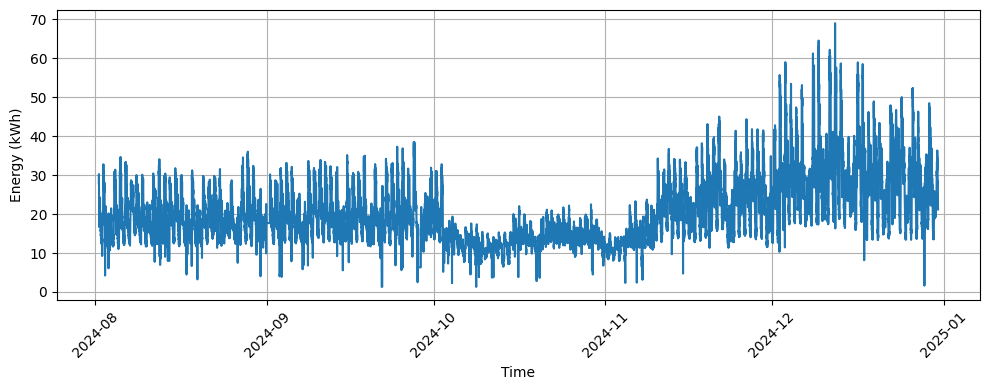

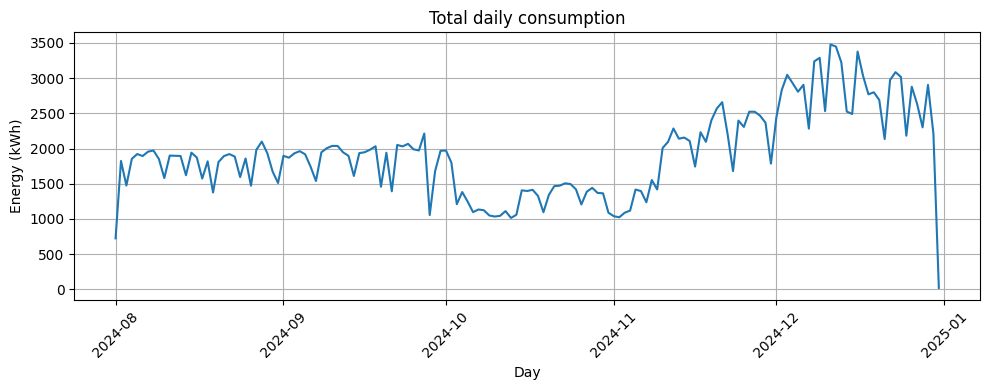

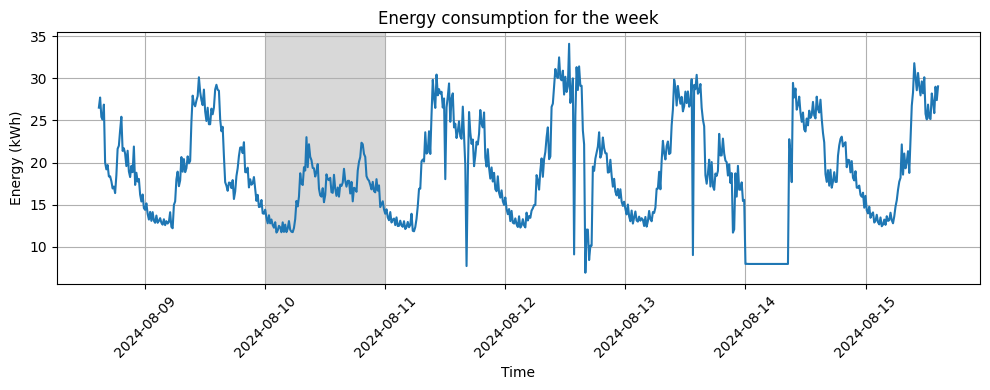

min    13.710728
max    27.700993
Name: Load_consumed (kWh), dtype: float64
sum    1938.986257
Name: Load_consumed (kWh), dtype: float64


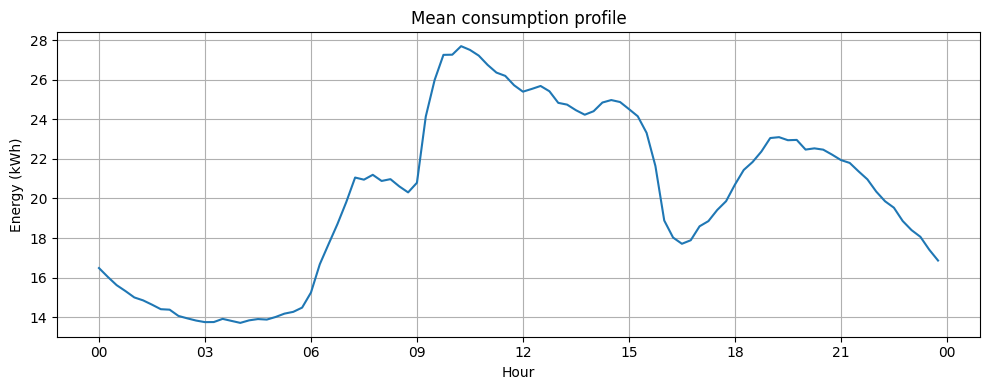

In [ ]:
# Filter and prepare data
first_nonzero_idx = df2[df2["Load_consumed (kWh)"] > 0].first_valid_index()
df2_filtered = df2.loc[first_nonzero_idx:]

# Plot 1: Full data
plt.figure(figsize=(10, 4))
ax = plt.gca()
plot_data(ax, df2)
plt.tight_layout()
plt.show()

# Plot 2: Daily consumption
temp_df = calculate_daily_consumption(df2_filtered)
plt.figure(figsize=(10, 4))
ax = plt.gca()
plot_daily_consumption(ax, temp_df)
plt.tight_layout()
plt.show()

# Plot 3: Single week
plt.figure(figsize=(10, 4))
ax = plt.gca()
plot_single_week(2, df2_filtered, ax)
plt.tight_layout()
plt.show()

# Plot 4: Mean profile
temp_df = calculate_mean_profile(df2_filtered)

print(temp_df.agg(['min', 'max']))
print(temp_df.agg(['sum']))

plt.figure(figsize=(10, 4))
ax = plt.gca()
plot_mean_profile(ax, temp_df)
plt.tight_layout()
plt.show()


min    13.710728
max    27.700993
Name: Load_consumed (kWh), dtype: float64
sum    1938.986257
Name: Load_consumed (kWh), dtype: float64


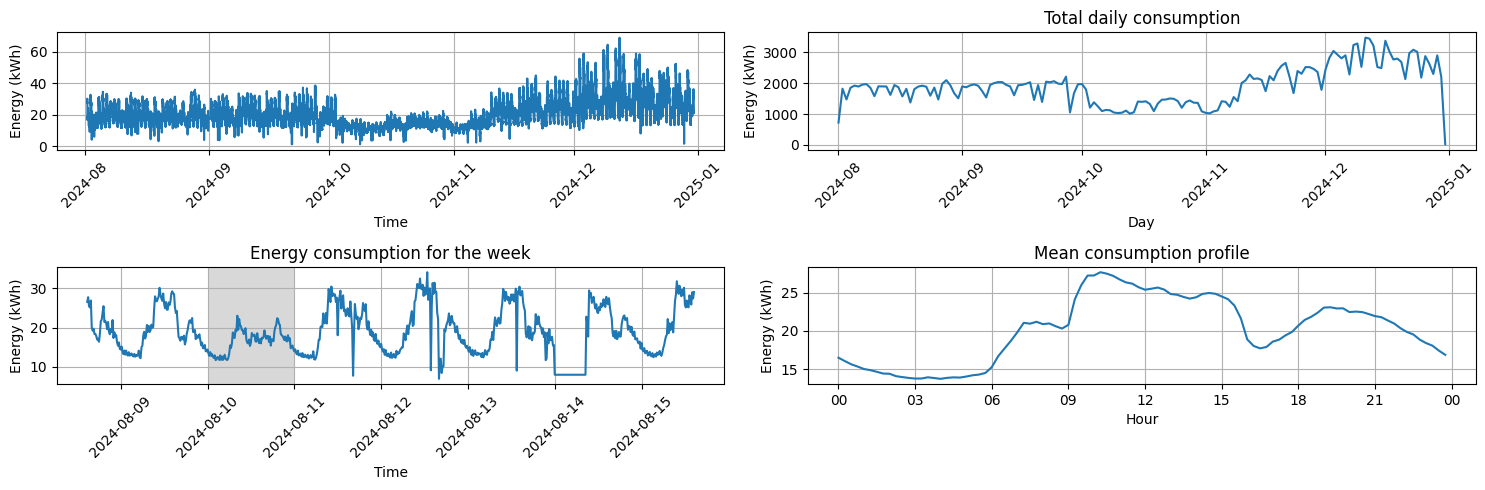

In [ ]:
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

first_nonzero_idx = df2[df2["Load_consumed (kWh)"] > 0].first_valid_index()
df2_filtered = df2.loc[first_nonzero_idx:]

temp_df = calculate_daily_consumption(df2_filtered)
temp_df.head(5)

plot_data(ax1,df2)

plot_daily_consumption(ax2,temp_df)

plot_single_week(2,df2_filtered,ax3)

temp_df = calculate_mean_profile(df2_filtered)

print(temp_df.agg(['min', 'max']))
print(temp_df.agg(['sum']))

plot_mean_profile(ax4, temp_df)

plt.tight_layout()
plt.show()


In [ ]:
df2_filtered.head()

,Load_consumed (kWh),air_temp,holiday,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,January,February,March,April,May,June,July,August,September,October,November
timestamp,,,,,,,,,,,,,,,,,,,,
2024-08-01 14:45:00,27.91,26.33,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2024-08-01 15:00:00,30.26,26.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2024-08-01 15:15:00,27.45,25.33,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2024-08-01 15:30:00,27.76,25.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2024-08-01 15:45:00,25.17,24.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
import plotly.express as px
week =2
fig = px.line(df2.iloc[(week-1)*7*96:week*96*7]["Load_consumed (kWh)"])
fig.update_xaxes(rangeslider_visible=True)
fig.show()




3.2 Visualizing distributions of energy consumption
While it is very interesting to observe the evolution of energy consumption over time, it can also be informative to analyze how often how much energy is consumed, i.e. the histogram of the values in the time series.

In most cases, consumption is very low and the distribution falls off rapidly as energy increases. However, there are peaks in the distribution that indicate recurring measurements with the same energy. These are indications of regularly running devices (see later section in the context of pre-processing).

Plotting the distribution with a logarithmic scale of the y-axis reveals peaks with lower counts at higher energy.

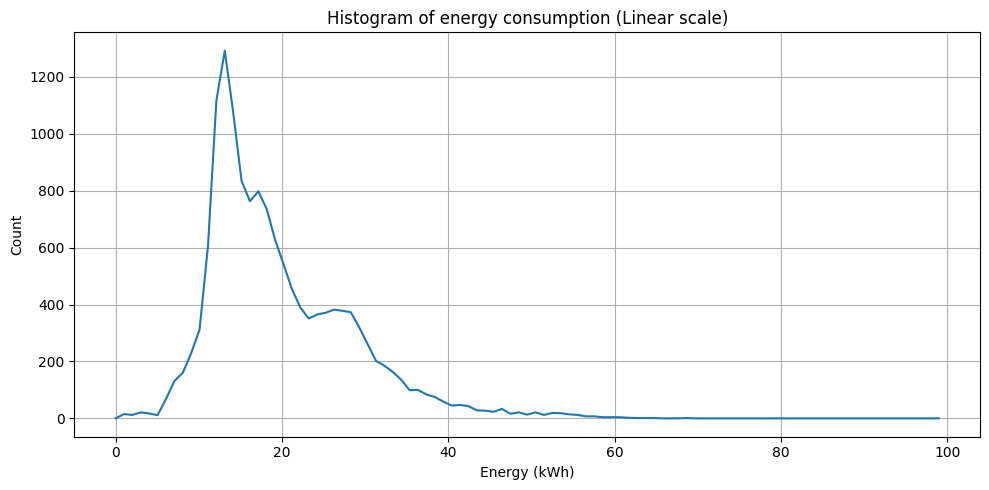

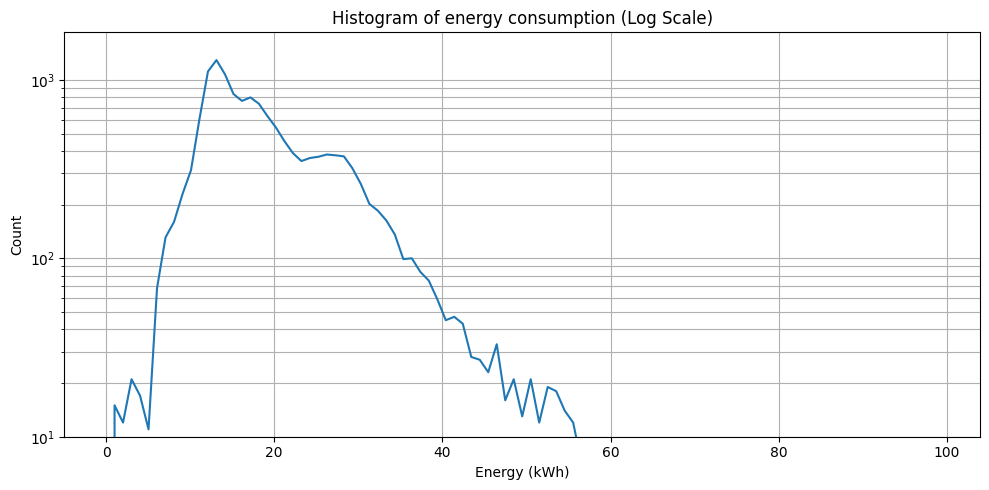

In [ ]:
# Define the energy intervals to use for the histogram
bins = np.linspace(0, 100, 100)

# Calculate the distribution of energy values
df2_hist, _ = np.histogram(df2['Load_consumed (kWh)'], bins=bins)

# Plot 1: Histogram (Linear Scale)
plt.figure(figsize=(10, 5))
plt.plot(bins[:-1], df2_hist)
plt.xlabel('Energy (kWh)')
plt.ylabel('Count')
plt.title('Histogram of energy consumption (Linear scale)')
plt.grid()
plt.tight_layout()
plt.show()

# Plot 2: Histogram (Logarithmic Scale)
plt.figure(figsize=(10, 5))
plt.plot(bins[:-1], df2_hist)
plt.yscale('log')
plt.ylim(10, None)  # Avoid taking log(0)
plt.xlabel('Energy (kWh)')
plt.ylabel('Count')
plt.title('Histogram of energy consumption (Log Scale)')
plt.grid(which='both')
plt.tight_layout()
plt.show()


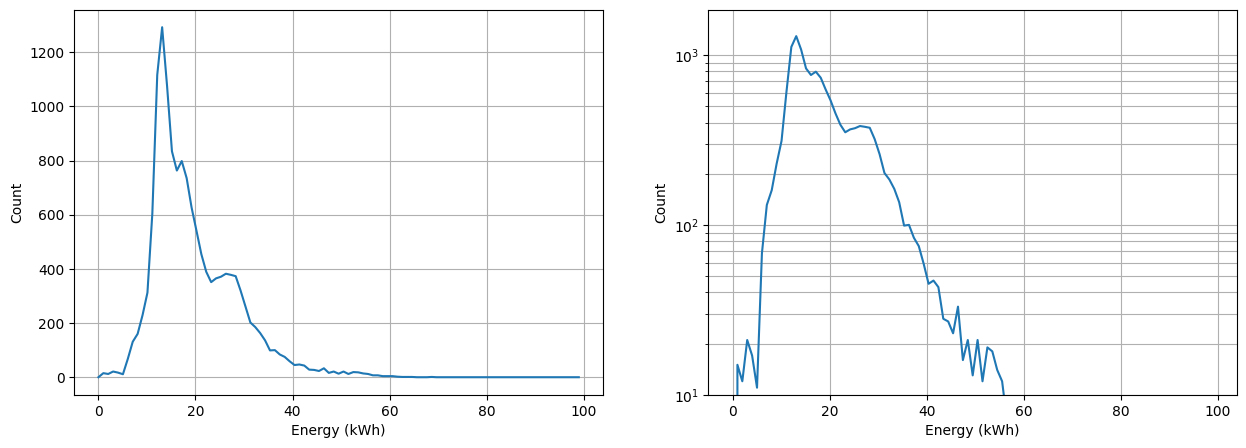

In [ ]:
# define the energy intervals to use for the histogram
bins = np.linspace(0, 100, 100)

# calculate the distribution of energy values
df2_hist, _ = np.histogram(df2['Load_consumed (kWh)'], bins=bins)

# define a figure with two columns
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# plot the histogram
ax[0].plot(bins[:-1], df2_hist)
ax[0].set_xlabel('Energy (kWh)')
ax[0].set_ylabel('Count')
ax[0].grid()

# plot the histogram on a logarithmic scale
ax[1].plot(bins[:-1], df2_hist)
ax[1].set_yscale('log')
ax[1].set_ylim(10, None)
ax[1].set_xlabel('Energy (kWh)')
ax[1].set_ylabel('Count')
ax[1].grid(which='both')

# MultiDimension Visualization

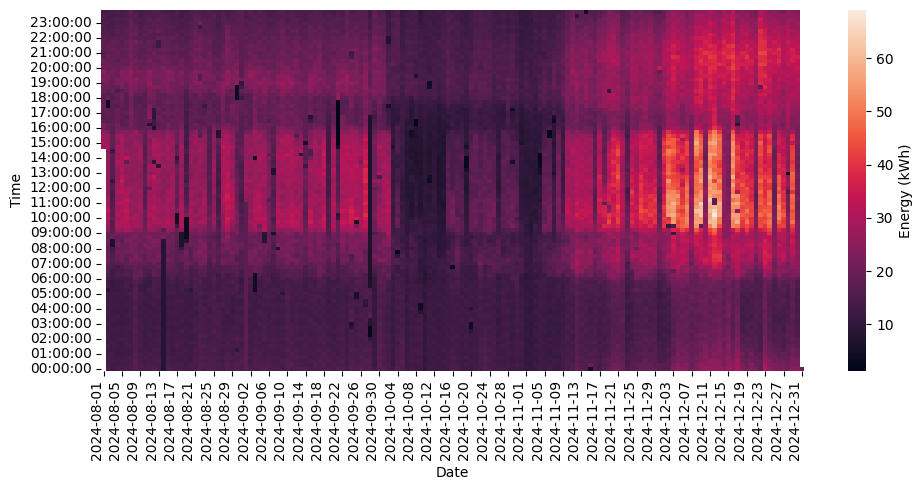

In [ ]:

def create_heatmap(df, column, interval_minutes=15):
  # As we will add additional columns and do not want the original data to be affected, create copy of the original data frame
  data_df = df.copy()
  # Add columns for date and time
  data_df["date"] = df.index.date
  data_df["time"] = df.index.time
  # Define a function that handles duplicate values which can occur in local time due to daylight savings time
  # Using only the first datapoint instead of summing avoids unrealistically height demand
  get_first = lambda x: x.iloc[0]

  data = data_df.pivot_table(index='time', columns='date', values=column, aggfunc=get_first, dropna=False)
  return data


#hm = create_heatmap(df2, column='Load_consumed (kWh)')

#fig_hm, ax_hm = plt.subplots(1, 1, figsize=(10, 5))

#sns.heatmap(hm, ax=ax_hm, cbar_kws={'label': 'Energy (kWh)'})

# Reverse the y-axis to show time in increasing order from bottom to top
#ax_hm.invert_yaxis()

#fig_hm.show()

hm = create_heatmap(df2, column='Load_consumed (kWh)')

fig_hm, ax_hm = plt.subplots(1, 1, figsize=(10, 5))

sns.heatmap(hm, ax=ax_hm, cbar_kws={'label': 'Energy (kWh)'})

# Reverse the y-axis to show time in increasing order from bottom to top
ax_hm.invert_yaxis()

# Capitalize axis labels
ax_hm.set_xlabel(ax_hm.get_xlabel().capitalize())
ax_hm.set_ylabel(ax_hm.get_ylabel().capitalize())
ax_hm.set_title(ax_hm.get_title().capitalize())

# Optionally capitalize tick labels on both axes
ax_hm.set_xticklabels([str(label.get_text()).capitalize() for label in ax_hm.get_xticklabels()], ha='right')
ax_hm.set_yticklabels([str(label.get_text()).capitalize() for label in ax_hm.get_yticklabels()])

fig_hm.tight_layout()
fig_hm.show()



In [ ]:
def find_holiday_indices(datetime_array,holiday_array):
    indices = []
    for i in range(len(datetime_array)):
        if holiday_array[i] == 1:
            indices.append(i)
    return indices

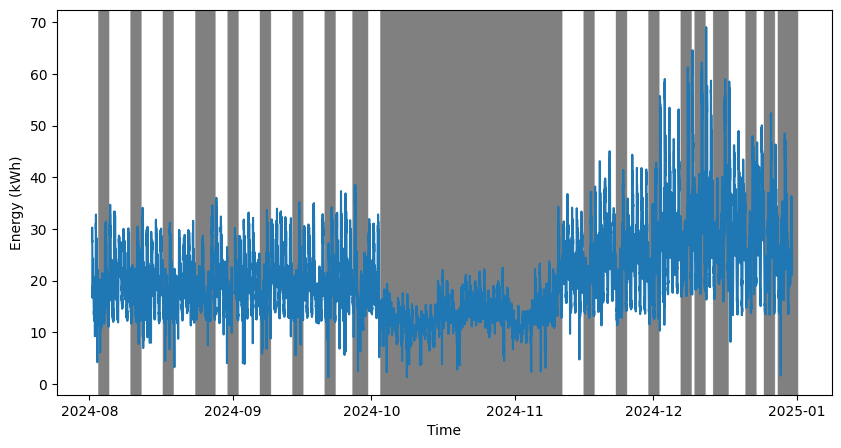

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot( df2["Load_consumed (kWh)"])
ax.set_xlabel('Time')
ax.set_ylabel('Energy (kWh)')
for date, is_holiday in df2.iterrows():
    if is_holiday["holiday"]:
        ax.axvspan(date, date + pd.Timedelta(days=1), color='gray', alpha=0.3)

                     Load_consumed (kWh)  air_temp  holiday  Sunday  Monday  \
timestamp                                                                     
2024-08-01 14:45:00                27.91     26.33        0       0       0   
2024-08-01 15:00:00                30.26     26.00        0       0       0   
2024-08-01 15:15:00                27.45     25.33        0       0       0   
2024-08-01 15:30:00                27.76     25.00        0       0       0   
2024-08-01 15:45:00                25.17     24.00        0       0       0   

                     Tuesday  Wednesday  Thursday  Friday  January  February  \
timestamp                                                                      
2024-08-01 14:45:00        0          0         1       0        0         0   
2024-08-01 15:00:00        0          0         1       0        0         0   
2024-08-01 15:15:00        0          0         1       0        0         0   
2024-08-01 15:30:00        0          0       

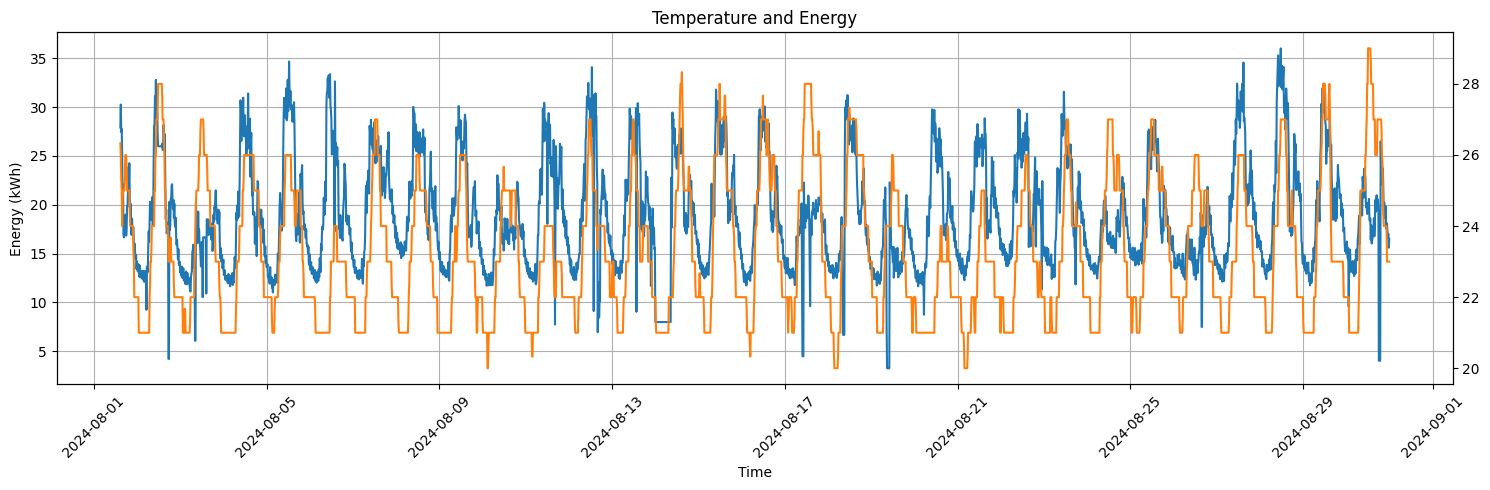

In [ ]:
data = df2["2024-08-01":"2024-08-30"]

print(data.head())

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.plot(data["Load_consumed (kWh)"])
ax2 = ax1.twinx()
ax2.plot(data["air_temp"], color="C1")
ax1.xaxis.set_tick_params(rotation=45)

ax1.set_xlabel('Time')
ax1.set_ylabel('Energy (kWh)')
ax2.set_title('Temperature and Energy')
ax1.grid()

plt.tight_layout()
plt.show()




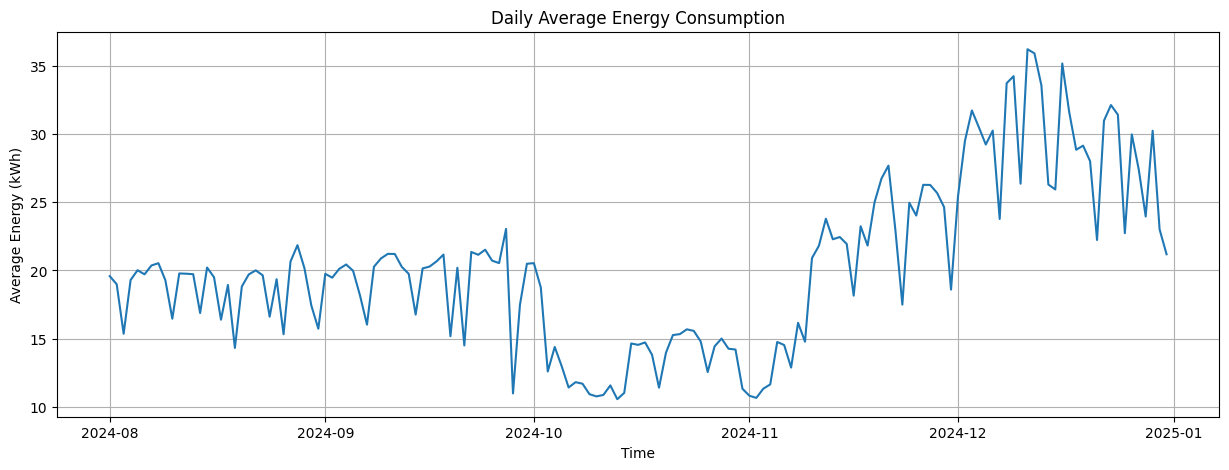

In [ ]:
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.plot(df2["Load_consumed (kWh)"].resample("1D").mean())
ax1.set_xlabel('Time')
ax1.set_ylabel('Average Energy (kWh)')
ax1.set_title('Daily Average Energy Consumption')
ax1.grid()


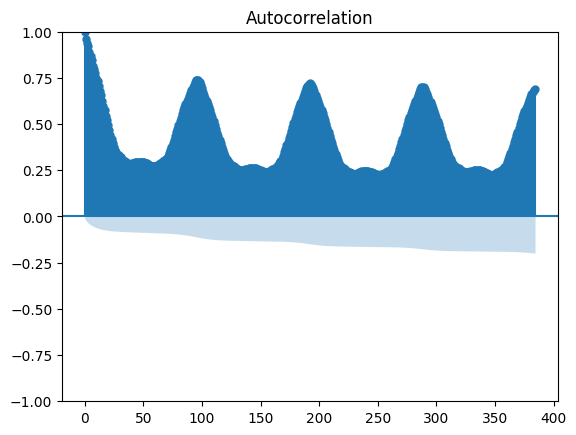

In [ ]:

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df2["Load_consumed (kWh)"], lags=4*96)
plt.show()